In [1]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00


In [53]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
def load_data(
    dataset_name: str = "Cora",
    data_dir: str = "/tmp/Planetoid",
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
) -> tuple[Data, torch.Tensor, torch.Tensor, torch.Tensor]:
    dataset = Planetoid(root=data_dir, name=dataset_name)
    data = dataset[0].to(device)

    return data, data.train_mask, data.val_mask, data.test_mask

In [ ]:
data, train_mask, val_mask, test_mask = load_data(
    dataset_name="Cora", data_dir="/tmp/Planetoid"
)
# Nodes are academic papers
# Edges are citation links between papers
# Node features are feature vectors indiciating words that appear in each paper/node
# Node labels are the paper/node's research topic/class

num_classes = data.y.max().item() + 1
print(f"There are {num_classes} classes")

Processing...
Done!


There are 7 classes


In [5]:
sum(data.train_mask).item()

140

In [6]:
# data.x are the nodes, representing papers with theire input features
# data.y are the class labels per paper/node
# data.edge_index represents the list of edges of the citation graph
data.x.shape, data.y.shape, data.edge_index.shape

(torch.Size([2708, 1433]), torch.Size([2708]), torch.Size([2, 10556]))

In [ ]:
class GraphConvolutionalNetwork(torch.nn.Module):
    def __init__(
        self,
        in_channels: int = 1433,
        hidden_channels: int = 16,
        out_channels: int = 7,
        dropout: float = 0.5,
    ):
        super().__init__()

        self.dropout = dropout

        self.conv_1 = GCNConv(in_channels=in_channels, out_channels=hidden_channels)
        self.conv_2 = GCNConv(in_channels=hidden_channels, out_channels=out_channels)

    def get_embeddings(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        # x shape: (N, in_channels)
        x = F.relu(self.conv_1(x, edge_index))  # x shape: (N, hidden_channels)

        return x

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        # x shape: (N, in_channels)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv_1(x, edge_index))  # x shape: (N, hidden_channels)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv_2(x, edge_index))  # x shape: (N, out_channels)

        return x

In [ ]:
class GraphAttentionNetwork(nn.Module):
    def __init__(
        self,
        in_channels: int = 1433,
        hidden_channels: int = 8,
        out_channels: int = 7,
        heads: int = 8,
        dropout: float = 0.6,
    ):
        super().__init__()

        self.dropout = dropout

        self.gat_conv_1 = GATConv(
            in_channels=in_channels,
            out_channels=hidden_channels,  # output_dim = hidden_channels * heads since concat=True
            heads=heads,
            concat=True,  # outputs from attention heads are concatenated
            dropout=dropout,
        )

        self.gat_conv_2 = GATConv(
            in_channels=hidden_channels * heads,
            out_channels=out_channels,
            heads=1,
            concat=False,  # outputs from attention heads are averaged
            dropout=dropout,
        )

    def get_embeddings(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        # x shape: (N, in_channels)
        x = F.elu(
            self.gat_conv_1(x, edge_index)
        )  # x shape: (N, hidden_channels * heads)

        return x

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        # x shape: (N, in_channels)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(
            self.gat_conv_1(x, edge_index)
        )  # x shape: (N, hidden_channels * heads)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat_conv_2(x, edge_index)  # x shape: (N, out_channels)

        return x

In [ ]:
gcn_model = GraphConvolutionalNetwork(
    in_channels=data.num_node_features,
    hidden_channels=64,
    out_channels=num_classes,
    dropout=0.5,
).to(device)

optimizer = torch.optim.Adam(params=gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()

print(
    f"The GCN model has: {sum(param.numel() for param in gcn_model.parameters()):,} total parameters"
)

The GCN model has: 92,231 total parameters


In [ ]:
def train_model(
    model: nn.Module,
    data: Data,
    train_mask: torch.Tensor,
    val_mask: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    num_epochs: int = 200,
) -> nn.Module:
    model.train()

    for epoch in tqdm(range(num_epochs), desc=f"Training for {num_epochs} epochs"):
        train_loss = 0.0
        val_loss = 0.0

        optimizer.zero_grad()

        logits = model(data.x, data.edge_index)
        loss = loss_fn(logits[train_mask], data.y[train_mask])
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()

            with torch.inference_mode():
                logits = model(data.x, data.edge_index)
                probs = torch.softmax(logits, dim=1)

                loss = loss_fn(logits[val_mask], data.y[val_mask])
                val_loss += loss.item()

                val_acc = (
                    torch.sum(probs[val_mask].argmax(dim=1) == data.y[val_mask])
                    / val_mask.sum()
                )
                print(
                    f"Epoch: {epoch} | Train Loss: {train_loss:.6f} | Validation Loss: {val_loss:.6f} | Validation Accuracy: {val_acc:.6f}"
                )

    return model

In [ ]:
def evaluate_model(
    model: nn.Module, data: Data, test_mask: torch.tensor, loss_fn: nn.Module
):
    test_loss = 0.0

    model.eval()

    with torch.inference_mode():
        logits = model(data.x, data.edge_index)
        probs = torch.softmax(logits, dim=1)

        loss = loss_fn(logits[test_mask], data.y[test_mask])
        test_loss += loss.item()

        test_acc = (
            torch.sum(probs[test_mask].argmax(dim=1) == data.y[test_mask])
            / test_mask.sum()
        )

        print(f"Test Loss: {test_loss:.6f} | Test Accuracy: {test_acc:.6f}")

In [ ]:
num_epochs = 200

gcn_model = train_model(
    model=gcn_model,
    data=data,
    train_mask=train_mask,
    val_mask=val_mask,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
)

Training for 200 epochs:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.940887 | Validation Loss: 1.902816 | Validation Accuracy: 0.416000
Epoch: 10 | Train Loss: 0.152986 | Validation Loss: 0.732775 | Validation Accuracy: 0.784000
Epoch: 20 | Train Loss: 0.008783 | Validation Loss: 0.778856 | Validation Accuracy: 0.768000
Epoch: 30 | Train Loss: 0.003552 | Validation Loss: 0.796600 | Validation Accuracy: 0.780000
Epoch: 40 | Train Loss: 0.004997 | Validation Loss: 0.778928 | Validation Accuracy: 0.776000
Epoch: 50 | Train Loss: 0.009366 | Validation Loss: 0.730686 | Validation Accuracy: 0.778000
Epoch: 60 | Train Loss: 0.012514 | Validation Loss: 0.717872 | Validation Accuracy: 0.776000
Epoch: 70 | Train Loss: 0.012258 | Validation Loss: 0.720550 | Validation Accuracy: 0.776000
Epoch: 80 | Train Loss: 0.011243 | Validation Loss: 0.722351 | Validation Accuracy: 0.772000
Epoch: 90 | Train Loss: 0.010667 | Validation Loss: 0.725046 | Validation Accuracy: 0.764000
Epoch: 100 | Train Loss: 0.010244 | Validation Loss: 0.728142 | Validat

In [ ]:
evaluate_model(model=gcn_model, data=data, test_mask=test_mask, loss_fn=loss_fn)

Test Loss: 0.617640 | Test Accuracy: 0.806000


In [ ]:
def predict_node(
    model: nn.Module,
    data: Data,
    node_idx: int,
    class_names: list[str] | None = None,
) -> tuple[torch.tensor, int]:
    model.eval()

    with torch.inference_mode():
        logits = model(data.x, data.edge_index)  # shape: (num_nodes, num_classes)
        probs = torch.softmax(logits, dim=1)

    node_probs = probs[node_idx]  # shape: (num_classes)
    pred_class = int(node_probs.argmax().item())

    print(f"Predicted class: {pred_class}")
    print(f"Actual class: {data.y[node_idx]}")

    return node_probs, pred_class

In [66]:
test_node_probs, test_pred_class = predict_node(model=gcn_model, data=data, node_idx=0)

Predicted class: 3
Actual class: 3


In [ ]:
def visualize_embeddings_tsne(
    model: nn.Module,
    data: Data,
    mask: torch.Tensor = None,
    title: str = "t-SNE of Graph Node Embeddings",
):
    model.eval()

    with torch.inference_mode():
        embeddings = model.get_embeddings(data.x, data.edge_index).cpu().numpy()

    labels = data.y.cpu().numpy()

    if mask is not None:
        mask = mask.cpu().numpy()
        embeddings = embeddings[mask]
        labels = labels[mask]

    tsne = TSNE(n_components=2, random_state=42, perplexity=50, init="pca")
    points_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(points_2d[:, 0], points_2d[:, 1], c=labels, s=20)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.colorbar(scatter, label="Class")

    plt.show()

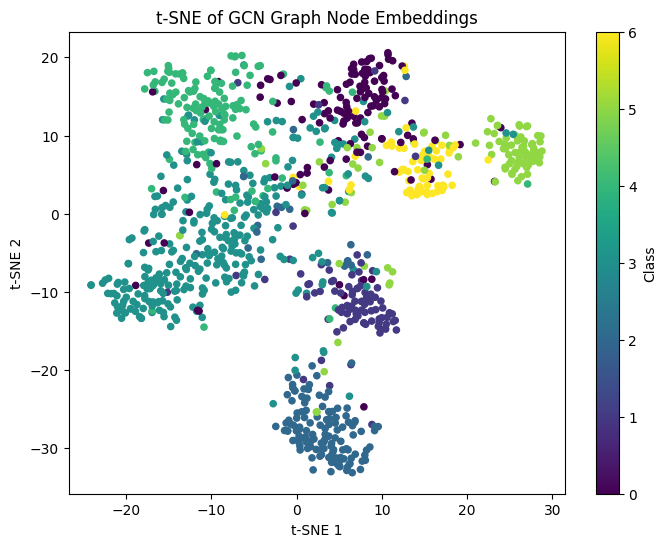

In [ ]:
visualize_embeddings_tsne(
    model=gcn_model,
    data=data,
    mask=test_mask,
    title="t-SNE of GCN Graph Node Embeddings",
)

In [ ]:
gat_model = GraphAttentionNetwork(
    in_channels=data.num_node_features,
    hidden_channels=8,
    out_channels=num_classes,
    heads=8,
    dropout=0.6,
).to(device)

optimizer = torch.optim.Adam(params=gat_model.parameters(), lr=0.005, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()

print(
    f"The GAT model has: {sum(param.numel() for param in gat_model.parameters()):,} total parameters"
)

The GAT model has: 92,373 total parameters


In [ ]:
num_epochs = 200

gat_model = train_model(
    model=gat_model,
    data=data,
    train_mask=train_mask,
    val_mask=val_mask,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
)

Training for 200 epochs:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.956586 | Validation Loss: 1.894014 | Validation Accuracy: 0.372000
Epoch: 10 | Train Loss: 0.460226 | Validation Loss: 0.940521 | Validation Accuracy: 0.772000
Epoch: 20 | Train Loss: 0.062030 | Validation Loss: 0.740662 | Validation Accuracy: 0.758000
Epoch: 30 | Train Loss: 0.013184 | Validation Loss: 0.812294 | Validation Accuracy: 0.738000
Epoch: 40 | Train Loss: 0.005422 | Validation Loss: 0.866448 | Validation Accuracy: 0.738000
Epoch: 50 | Train Loss: 0.004601 | Validation Loss: 0.880051 | Validation Accuracy: 0.740000
Epoch: 60 | Train Loss: 0.005474 | Validation Loss: 0.867460 | Validation Accuracy: 0.736000
Epoch: 70 | Train Loss: 0.006808 | Validation Loss: 0.845287 | Validation Accuracy: 0.742000
Epoch: 80 | Train Loss: 0.007832 | Validation Loss: 0.830875 | Validation Accuracy: 0.756000
Epoch: 90 | Train Loss: 0.008103 | Validation Loss: 0.827820 | Validation Accuracy: 0.760000
Epoch: 100 | Train Loss: 0.007748 | Validation Loss: 0.832576 | Validat

In [ ]:
evaluate_model(model=gat_model, data=data, test_mask=test_mask, loss_fn=loss_fn)

Test Loss: 0.695169 | Test Accuracy: 0.779000


In [79]:
test_node_probs, test_pred_class = predict_node(model=gat_model, data=data, node_idx=0)

Predicted class: 3
Actual class: 3


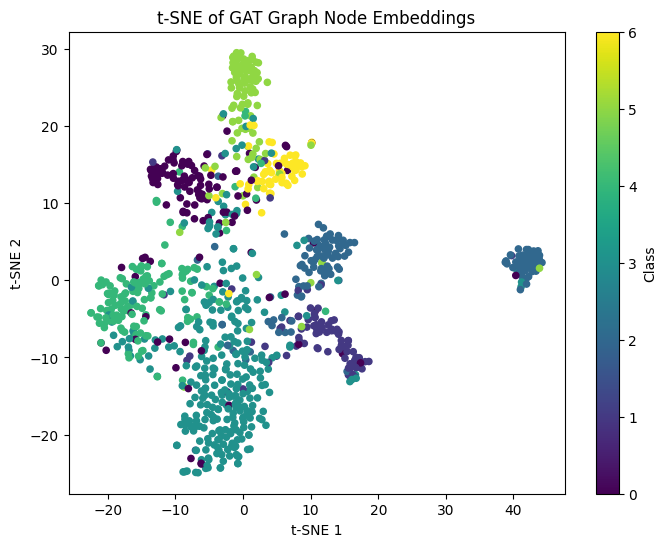

In [ ]:
visualize_embeddings_tsne(
    model=gat_model,
    data=data,
    mask=test_mask,
    title="t-SNE of GAT Graph Node Embeddings",
)